Loading dataset...
Dataset ready!

========== 5-FOLD CROSS VALIDATION ==========
Support:
Fresh: 806
Rotten: 1085

--- Fold 1 ---
Accuracy: 0.9931253305129562
Precision: 0.9926470588235294
Recall: 0.9953917050691244
F1: 0.9940174873446848
Log Loss: 0.03453572526468616
RMSE: 0.0829136266668145
MAE: 0.006874669487043892
R²: 0.971889400921659
Support:
Fresh: 806
Rotten: 1085

--- Fold 2 ---
Accuracy: 0.9989423585404548
Precision: 1.0
Recall: 0.9981566820276497
F1: 0.9990774907749077
Log Loss: 0.029736264247041275
RMSE: 0.032521400024371865
MAE: 0.0010576414595452142
R²: 0.995675292449486
Support:
Fresh: 805
Rotten: 1086

--- Fold 3 ---
Accuracy: 0.9962982548915917
Precision: 0.9945004582951421
Recall: 0.9990791896869244
F1: 0.9967845659163987
Log Loss: 0.014229282643517457
RMSE: 0.06084196831471061
MAE: 0.0037017451084082496
R²: 0.9848586756345584
Support:
Fresh: 805
Rotten: 1085

--- Fold 4 ---
Accuracy: 0.9936507936507937
Precision: 0.9935602575896965
Recall: 0.9953917050691244
F1: 0.99

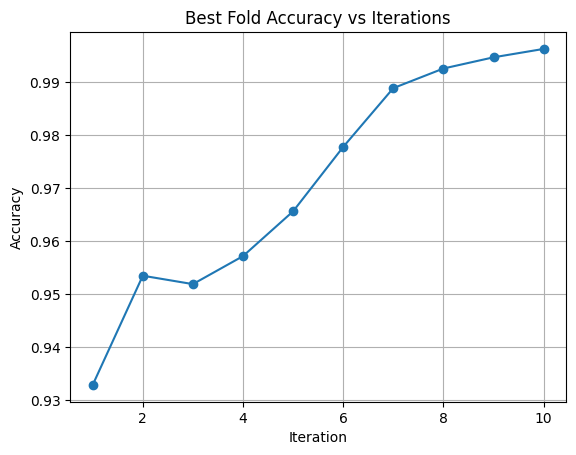

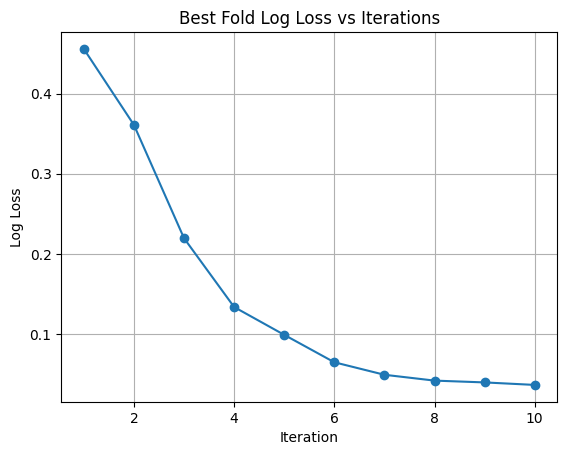


========== AVERAGE METRICS (5-FOLD) ==========
ACCURACY: 0.9951
PRECISION: 0.9950
RECALL: 0.9965
F1: 0.9958
LOGLOSS: 0.0272
RMSE: 0.0671
MAE: 0.0049
R2: 0.9801

TOTAL EXECUTION TIME: 279.49 seconds


In [3]:
import cv2
import os
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
mean_squared_error,
mean_absolute_error,
log_loss,
r2_score
)
from sklearn.neighbors import KNeighborsClassifier

from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy


# ============================================================
# FEATURE EXTRACTION
# ============================================================
def extract_features(img):
    img = cv2.resize(img, (256, 256))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]
    _, mask = cv2.threshold(s, 30, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    circularity = (4 * np.pi * area) / (perimeter ** 2 + 1e-6)

    hull = cv2.convexHull(cnt)
    solidity = area / (cv2.contourArea(hull) + 1e-6)

    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = w / h
    extent = area / (w * h + 1e-6)

    R, G, B = cv2.split(img)
    R_mean, R_std = cv2.meanStdDev(R, mask=mask)
    G_mean, G_std = cv2.meanStdDev(G, mask=mask)
    B_mean, B_std = cv2.meanStdDev(B, mask=mask)

    H, S, V = cv2.split(hsv)
    H_mean, H_std = cv2.meanStdDev(H, mask=mask)
    S_mean, S_std = cv2.meanStdDev(S, mask=mask)
    V_mean, V_std = cv2.meanStdDev(V, mask=mask)

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L, A, B_lab = cv2.split(lab)
    L_mean, L_std = cv2.meanStdDev(L, mask=mask)
    a_mean, a_std = cv2.meanStdDev(A, mask=mask)
    b_mean, b_std = cv2.meanStdDev(B_lab, mask=mask)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_masked = cv2.bitwise_and(gray, gray, mask=mask)

    laplacian_variance = cv2.Laplacian(gray_masked, cv2.CV_64F).var()

    glcm = graycomatrix(gray_masked, [1], [0], 256, symmetric=True, normed=True)
    glcm_contrast = graycoprops(glcm, 'contrast')[0, 0]
    glcm_energy = graycoprops(glcm, 'energy')[0, 0]
    glcm_homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

    hist = cv2.calcHist([gray_masked], [0], mask, [256], [0, 256])
    hist_norm = hist / hist.sum()
    grayscale_entropy = entropy(hist_norm.flatten())

    dark_pixel_ratio = np.sum(gray_masked < 50) / (np.sum(mask > 0) + 1e-6)

    return [
        R_mean[0][0], G_mean[0][0], B_mean[0][0],
        R_std[0][0], G_std[0][0], B_std[0][0],
        H_mean[0][0], S_mean[0][0], V_mean[0][0],
        H_std[0][0], S_std[0][0], V_std[0][0],
        L_mean[0][0], L_std[0][0],
        a_mean[0][0], a_std[0][0],
        b_mean[0][0], b_std[0][0],
        laplacian_variance,
        glcm_contrast,
        glcm_energy,
        glcm_homogeneity,
        grayscale_entropy,
        area, perimeter, circularity, solidity,
        aspect_ratio, extent,
        dark_pixel_ratio
    ]


# ============================================================
# LOAD DATASET
# ============================================================
dataset_path = r"C:\Users\KIIT0001\Downloads\archive (5)\train"
data = []

start_time = time.time()
print("Loading dataset...")

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue

    label = "Rotten" if "rotten" in folder.lower() else "Fresh"

    for img_name in os.listdir(folder_path):
        img = cv2.imread(os.path.join(folder_path, img_name))
        if img is None:
            continue

        feat = extract_features(img)
        if feat is not None:
            data.append(feat + [label])

print("Dataset ready!")

df = pd.DataFrame(data)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)


# ============================================================
# STRATIFIED 5-FOLD CROSS VALIDATION
# ============================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "logloss": [],
    "rmse": [],
    "mae": [],
    "r2": []
}

best_accuracy = 0
best_fold_data = None
support_per_fold = []

print("\n========== 5-FOLD CROSS VALIDATION ==========")

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    y_prob = knn.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    ll = log_loss(y_test, y_prob)

    metrics["accuracy"].append(acc)
    metrics["precision"].append(precision_score(y_test, y_pred))
    metrics["recall"].append(recall_score(y_test, y_pred))
    metrics["f1"].append(f1_score(y_test, y_pred))
    metrics["logloss"].append(ll)
    metrics["rmse"].append(rmse)
    metrics["mae"].append(mae)
    metrics["r2"].append(r2)

    unique, counts = np.unique(y_test, return_counts=True)
    fold_support = dict(zip(unique, counts))
    support_per_fold.append(fold_support)

    print("Support:")
    for cls, count in fold_support.items():
        print(f"{le.inverse_transform([cls])[0]}: {count}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_fold_data = (X_train, X_test, y_train, y_test)

    print(f"\n--- Fold {fold} ---")
    print("Accuracy:", acc)
    print("Precision:", metrics["precision"][-1])
    print("Recall:", metrics["recall"][-1])
    print("F1:", metrics["f1"][-1])
    print("Log Loss:", ll)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R²:", r2)

# ============================================================
# AVERAGE SUPPORT (5-FOLD)
# ============================================================
print("\n========== AVERAGE SUPPORT (5-FOLD) ==========")

# Convert list of dictionaries to DataFrame
support_df = pd.DataFrame(support_per_fold).fillna(0)

# Rename columns to actual class names
support_df.columns = le.inverse_transform(support_df.columns.astype(int))

# Compute average support
avg_support = support_df.mean()

for cls in avg_support.index:
    print(f"{cls}: {avg_support[cls]:.2f}")


# ============================================================
# ITERATIVE ANALYSIS ON BEST FOLD ONLY
# ============================================================
X_train_best, X_test_best, y_train_best, y_test_best = best_fold_data

iterations = []
accuracies = []
losses = []

fractions = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.85,0.9]

print("\n========== ITERATIVE ANALYSIS (BEST FOLD) ==========")

for i, frac in enumerate(fractions, 1):
    X_tr, _, y_tr, _ = train_test_split(
        X_train_best, y_train_best,
        train_size=frac,
        stratify=y_train_best,
        random_state=42
    )

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr, y_tr)

    y_pred = knn.predict(X_test_best)
    y_prob = knn.predict_proba(X_test_best)

    acc = accuracy_score(y_test_best, y_pred)
    loss = log_loss(y_test_best, y_prob)

    iterations.append(i)
    accuracies.append(acc)
    losses.append(loss)

    print(f"Iteration {i} | Train {int(frac*100)}% | Accuracy {acc:.4f} | Log Loss {loss:.4f}")


# ============================================================
# PLOTS (BEST FOLD ONLY)
# ============================================================
plt.figure()
plt.plot(iterations, accuracies, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Best Fold Accuracy vs Iterations")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(iterations, losses, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Best Fold Log Loss vs Iterations")
plt.grid(True)
plt.show()


# ============================================================
# AVERAGE METRICS
# ============================================================
print("\n========== AVERAGE METRICS (5-FOLD) ==========")
for key in metrics:
    print(f"{key.upper()}: {np.mean(metrics[key]):.4f}")

print(f"\nTOTAL EXECUTION TIME: {time.time() - start_time:.2f} seconds")
